# Guided DDIM Reconstruction – `train_large_ladiff` model

Test the diffusion model trained with `train_large_ladiff.py` on pre-computed
`la_fbp` / `gt_fbp` volumes saved by the **Large_LA_Dataset** notebook.

**Pipeline:**
1. Load `la_fbp.npy` / `gt_fbp.npy` and the percentile norm sidecar JSON.
2. Load the matching projections from disk (same setup as Large_LA_Dataset).
3. Load the trained UNet checkpoint.
4. For each test slice: run Guided DDIM with per-slice sinogram consistency.
5. Compute PSNR and SSIM vs. ground truth.


## 1. Imports & Setup

In [1]:
import sys, importlib, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

from ladiff.fourier_wedge import (
    build_missing_wedge_mask,
    apply_missing_wedge,
    inpaint_fourier_wedge,
)

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Metrics ───────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

import lovely_tensors as lt
lt.monkey_patch()

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

def apply_circle_mask(img):
    W, H = img.shape[-2:]
    cp = torch.cartesian_prod(torch.arange(W, device=img.device), torch.arange(H, device=img.device))
    circle_mask = (cp[:, 0] - W / 2) ** 2 + (cp[:, 1] - W / 2) ** 2 <= (W / 2) ** 2
    return img * circle_mask.reshape(img.shape[-2:])

zarr not installed


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 2. Configuration

These parameters must match the **Large_LA_Dataset** notebook used to produce the saved volumes.

In [2]:
# ── Must match Large_LA_Dataset notebook ──────────────────────────────────
FILE_IDX         = 1
DATA_PATH        = Path(f'/myhome/data/sdate/shared/compression_paper/small/file_{FILE_IDX}_extracted')
DOWNSCALE_FACTOR = 2.0
ANGULAR_RANGE_FRAC = 0.6   # fraction of projections used as la (must match notebook)
DET_SPACING_MM   = 1.0
LAMINO_ANGLE_DEG = 0.0

# ── Saved volume paths (output of Large_LA_Dataset) ───────────────────────
RECON_PATH = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction')
GT_FBP_PATH  = RECON_PATH / f'gt_fbp_{FILE_IDX}.npy'
NORM_JSON    = RECON_PATH / f'training/la_fourier_{FILE_IDX}_norm.json'

# ── Checkpoint (output of train_large_ladiff.py) ──────────────────────────
CHECKPOINT_PATH  = project_root / 'checkpoints' / f'ddpm_large_ladiff_file_{FILE_IDX}.pt'
TINY_MODEL       = False   # set True if trained with --tiny

# ── Inference ─────────────────────────────────────────────────────────────
NUM_INFERENCE_STEPS = 50

# ── Test slices: indices into the la_fbp volume (0 .. num_slices-1) ───────
# Set to None to test every TEST_STRIDE-th slice across the whole volume.
TEST_SLICE_INDICES = None   # e.g. [50, 100, 150] or None for automatic
TEST_STRIDE        = 20     # used when TEST_SLICE_INDICES is None

# ── Guidance hyperparams ──────────────────────────────────────────────────
GUIDANCE_MAX_EPOCHS = 5
GUIDANCE_LR         = 1e-3
GUIDANCE_BATCH_SIZE = 30

print("Configuration set ✅")


Configuration set ✅


## 3. Load Saved Volumes and Normalization

In [3]:
gt_fbp = torch.tensor(np.load(GT_FBP_PATH))   # (num_slices, H, W)
print(f"gt_fbp shape : {gt_fbp.shape}  [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}]")

# ── Normalization from sidecar JSON ───────────────────────────────────────
with open(NORM_JSON) as f:
    norm_cfg = json.load(f)

norm_min = float(norm_cfg['norm_min'])
norm_max = float(norm_cfg['norm_max'])
print(f"\nNorm (p1–p99): min={norm_min:.4f}, max={norm_max:.4f}")

# Normalization functions: raw ↔ [0, 1]
def normalize_fn(x):
    return (x - norm_min) / (norm_max - norm_min)

def denormalize_fn(x):
    return x * (norm_max - norm_min) + norm_min

NUM_SLICES, SLICE_H, SLICE_W = gt_fbp.shape
print(f"\nVolume: {NUM_SLICES} slices of {SLICE_H}×{SLICE_W}")


gt_fbp shape : torch.Size([540, 640, 640])  [-0.0595, 0.0826]

Norm (p1–p99): min=-0.0008, max=0.0033

Volume: 540 slices of 640×640


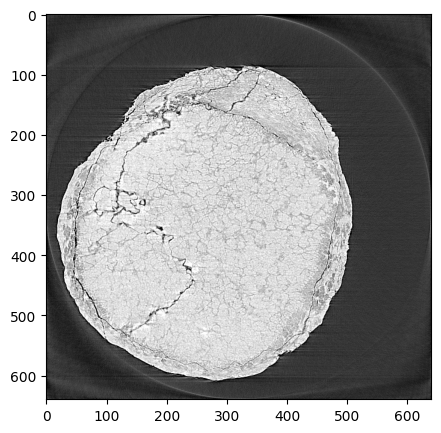

In [4]:
plt.imshow(gt_fbp[0], vmin=norm_min, vmax=norm_max)

In [5]:
# NUM_SLICES = 2
# gt_fbp = gt_fbp[:NUM_SLICES]

NUM_SLICES = 32
gt_fbp = gt_fbp[0].unsqueeze(0).repeat(32, 1, 1)

gt_fbp


tensor[32, 640, 640] n=13107200 (50Mb) x∈[-0.006, 0.007] μ=0.001 σ=0.001

## 4. Compute LA Fourier reconstruction

In [6]:
# ── Parameters ────────────────────────────────────────────────────────────────
ANGULAR_RANGE_DEG = int(ANGULAR_RANGE_FRAC * 180)   # 108 for ANGULAR_RANGE_FRAC=0.6
START_ANGLE       = 10.0    # degrees; tilt starts here, runs to START_ANGLE + ANGULAR_RANGE_DEG
TILT_AXIS         = 0      # axis the sample rotates around: 0=kz  1=ky  2=kx

la_fbp = apply_missing_wedge(gt_fbp.to(device), ANGULAR_RANGE_DEG, START_ANGLE, TILT_AXIS).cpu()
la_fbp

la_fbp = apply_circle_mask(la_fbp)
gt_fbp = apply_circle_mask(gt_fbp)

## 5. Visualise a Sample Slice

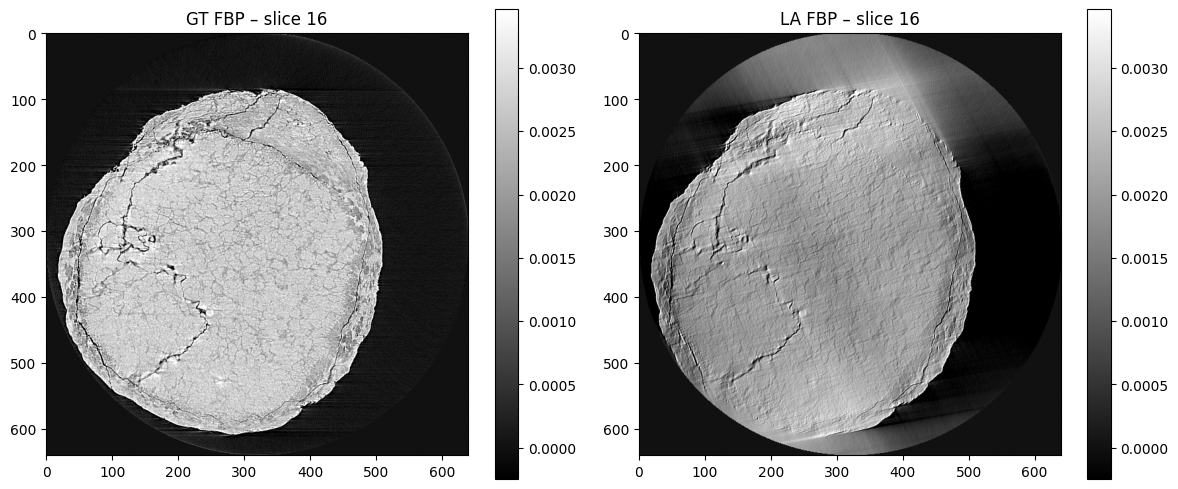

GT  range: [-0.0059, 0.0073]
LA  range: [-0.0038, 0.0069]
Norm [0,1] range covers p1=-0.0008 – p99=0.0033


In [7]:
PREVIEW_IDX = NUM_SLICES // 2

# PREVIEW_IDX = 0

gt_slice  = gt_fbp[PREVIEW_IDX]
la_slice  = la_fbp[PREVIEW_IDX]
vmin, vmax = np.percentile(gt_slice, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gt_slice, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(f'GT FBP – slice {PREVIEW_IDX}')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(la_slice, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'LA FBP – slice {PREVIEW_IDX}')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

print(f"GT  range: [{gt_slice.min():.4f}, {gt_slice.max():.4f}]")
print(f"LA  range: [{la_slice.min():.4f}, {la_slice.max():.4f}]")
print(f"Norm [0,1] range covers p1={norm_min:.4f} – p99={norm_max:.4f}")


## 6. Load Trained Diffusion Model

In [8]:
CHECKPOINT_PATH = project_root / 'checkpoints' / f'ddpm_large_ladiff.pt'

In [9]:
channels = (32, 32, 32, 32, 64, 64) if TINY_MODEL else (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=SLICE_W,   # slices are (SLICE_H, SLICE_W); model expects square → use W
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  in/out channels: 1 / 1  (single 2-D slice)")


Model loaded from /myhome/sdate/checkpoints/ddpm_large_ladiff.pt
  Parameters : 28,444,929
  in/out channels: 1 / 1  (single 2-D slice)


tensor[640, 640] n=409600 (1.6Mb) x∈[-0.791, 1.000] μ=0.463 σ=0.262 cuda:0

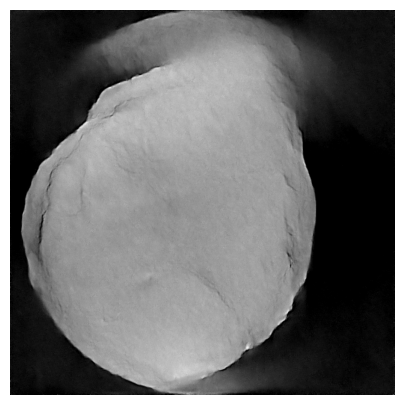

In [10]:
scheduler = GuidedDDIMScheduler(1000)
scheduler.set_timesteps(NUM_INFERENCE_STEPS)
timestep = 250
x_t = scheduler.add_noise(normalize_fn(la_fbp[0]).clip(0, 1), torch.randn_like(la_slice), timesteps=torch.tensor([timestep])).to(device)
with torch.no_grad():
    noise_pred = model(x_t.unsqueeze(0).unsqueeze(0), timestep = torch.tensor([timestep]).to(device), return_dict=False)[0].squeeze()  # (H, W)
    x_0_pred = scheduler.step(noise_pred, timestep=timestep, sample=x_t)['pred_original_sample']  # (H, W)
    diffusion_pred = denormalize_fn(x_0_pred)
    # diffusion_pred = inpaint_guidance(
    #     source_volume=gt_slice.unsqueeze(0).to(device),              # oracle: original full-angle tensor on device
    #     vol_init=diffusion_pred.unsqueeze(0).to(device)
    # )
plt.imshow(diffusion_pred.squeeze().cpu(), cmap='gray', vmin=vmin, vmax=vmax)
plt.axis('off')
x_0_pred

/tmp/ipykernel_1074/144643009.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, w_pad=0.15)


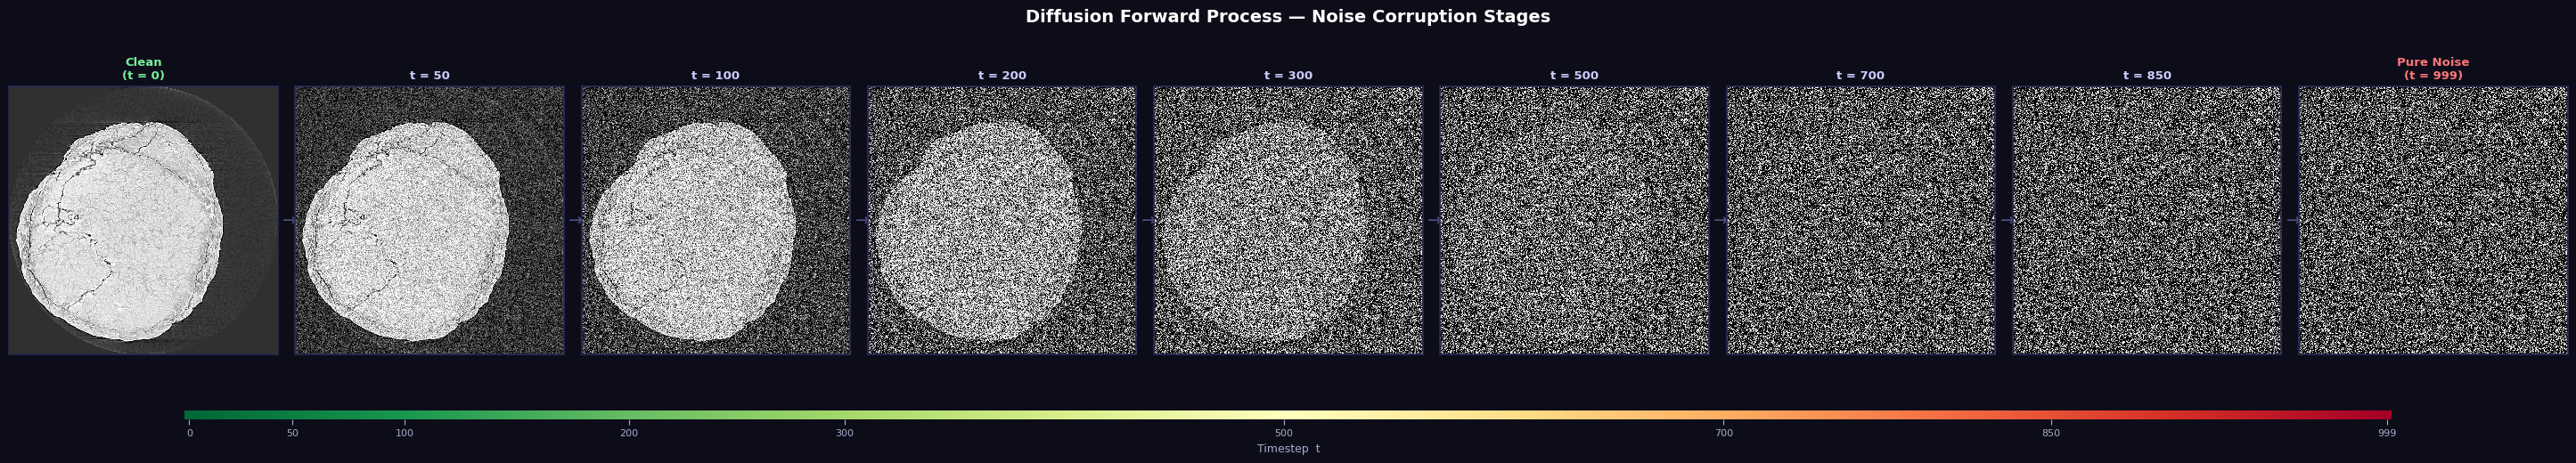

In [11]:

# ── Diffusion Forward Process: Corruption Stages ──────────────────────────
NOISE_TIMESTEPS = [0, 50, 100, 200, 300, 500, 700, 850, 999]

_sched_vis = GuidedDDIMScheduler(num_train_timesteps=1000)
_clean_vis = normalize_fn(gt_fbp[0]).clip(0, 1)      # (H, W)
_noise_vis = torch.randn_like(_clean_vis)

# Collect noisy images at each timestep
noisy_images = []
with torch.no_grad():
    for t in NOISE_TIMESTEPS:
        if t == 0:
            noisy_images.append(_clean_vis.cpu().numpy())
        else:
            x_t = _sched_vis.add_noise(
                _clean_vis.unsqueeze(0).unsqueeze(0).to(device),
                _noise_vis.unsqueeze(0).unsqueeze(0).to(device),
                timesteps=torch.tensor([t]),
            )
            noisy_images.append(x_t.squeeze().cpu().numpy())

# ── Figure ────────────────────────────────────────────────────────────────
ncols = len(NOISE_TIMESTEPS)
fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols, 4.2), facecolor='#0d0d1a')
fig.suptitle(
    'Diffusion Forward Process — Noise Corruption Stages',
    color='white', fontsize=14, fontweight='bold', y=1.04,
)

for i, (ax, t, img) in enumerate(zip(axes, NOISE_TIMESTEPS, noisy_images)):
    ax.set_facecolor('#0d0d1a')
    ax.imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')

    if i == 0:
        title, color = f'Clean\n(t = 0)', '#77ee99'
    elif i == ncols - 1:
        title, color = f'Pure Noise\n(t = {t})', '#ff7777'
    else:
        title, color = f't = {t}', '#ccccff'

    ax.set_title(title, color=color, fontsize=9.5, fontweight='bold', pad=6)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#2a2a55')
        spine.set_linewidth(1.2)

    # Progress arrow between panels (using figure text instead of annotation)
    if i < ncols - 1:
        ax.text(
            1.045, 0.5, '→',
            transform=ax.transAxes,
            color='#555588', fontsize=14,
            ha='center', va='center',
        )

# Noise level bar below the panels
noise_fracs = [t / 999 for t in NOISE_TIMESTEPS]
bar_ax = fig.add_axes([0.07, -0.06, 0.86, 0.025])
gradient = np.linspace(0, 1, 256).reshape(1, -1)
bar_ax.imshow(gradient, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
bar_ax.set_yticks([])
bar_ax.set_xticks([int(f * 255) for f in noise_fracs])
bar_ax.set_xticklabels([str(t) for t in NOISE_TIMESTEPS], color='#aaaacc', fontsize=8)
bar_ax.set_xlabel('Timestep  t', color='#aaaacc', fontsize=9, labelpad=4)
bar_ax.tick_params(colors='#aaaacc', length=4)
for spine in bar_ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=0.3, w_pad=0.15)
plt.show()


## 7. Guidance Function

At each DDIM step the scheduler calls `guidance_fn(x_0_raw, t)` where `x_0_raw` is the predicted clean image in **raw** (un-normalised) space with shape `(1, 1, H, W)`.  We run a few GD iterations of `gd_reconstruction_masked` using the limited-angle projections for the current slice to enforce data consistency, then return the updated estimate in the same shape.

In [12]:
def inpaint_guidance(
    source_volume: torch.Tensor,        # (D, H, W) — original full-angle volume (oracle)
    vol_init: torch.Tensor,        # (D, H, W) — current denoised estimate
    timestep: int = 0,                   # current diffusion timestep
    inpaint_steps: int = 1                     # apply inpainting every inpaint_steps steps
) -> torch.Tensor:
    """Apply GD guidance using limited-angle data.

    If ``sw_projs_vrc`` is provided and ``timestep > sw_threshold``, uses the
    combined sliding-window projections from all frames.  Otherwise, falls back
    to the middle frame's projections only (original behaviour).

    Parameters:
    -----------
    source_volume : torch.Tensor
        Original full-angle volume (oracle).
    vol_init : torch.Tensor
        Current denoised estimate.
    timestep : int
        Current diffusion timestep

    Returns
    -------
    recon : (D, H, W)
    """
    if (timestep // 20) % inpaint_steps == 0:
        recon = inpaint_fourier_wedge(
            target_volume    = vol_init.to(device),   # float32 tensor on device
            source_volume    = source_volume.to(device),              # oracle: original full-angle tensor on device
            angular_range_deg= 180 - ANGULAR_RANGE_DEG,
            start_angle_deg  = START_ANGLE - 80,  # center the missing wedge around START_ANGLE
            tilt_axis        = TILT_AXIS,
        )
        return recon
    else:
        return vol_init


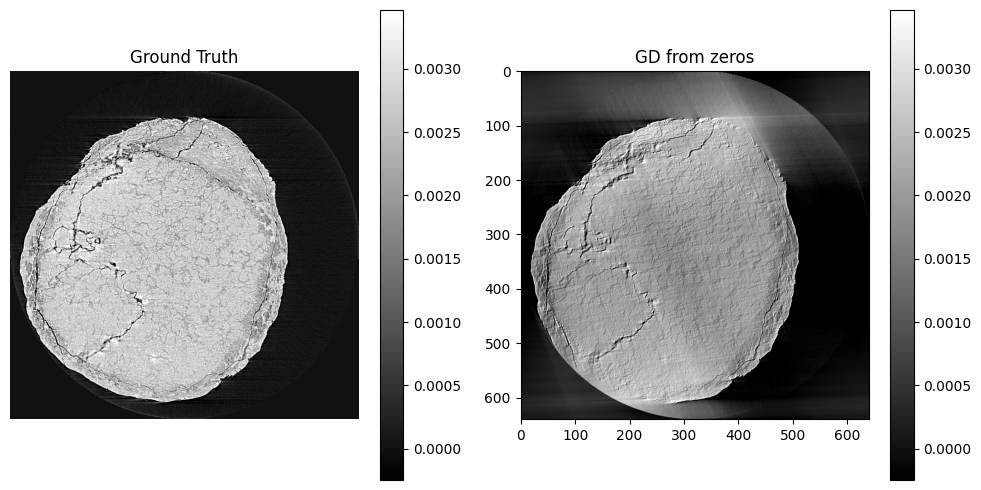

In [13]:
TEST_SLICE_IDX = NUM_SLICES // 2 
# Quick test: guidance from zero initialisation (uses SW projections since t=999 > threshold)
recons_gd = inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=la_fbp.to(device),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gt_fbp[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
plt.colorbar(axes[0].images[0], ax=axes[0])
axes[1].imshow(recons_gd[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(axes[1].images[0], ax=axes[1])
axes[1].set_title(f'GD from zeros')
plt.tight_layout()
plt.show()

In [14]:
guidance = lambda x, t: inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=x.to(device),
    timestep=int(t),
    inpaint_steps=1
)

# guidance = lambda x, t: x

## 8. Run Guided DDIM on a Single Test Slice

Quick sanity check before the full sweep.

In [16]:
diffusion_recon = la_fbp.clone().to(device)
# diffusion_recon = iterative_recon

In [17]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 40

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    fdk_prior=None,
    normalize_fn=normalize_fn,
    denormalize_fn=denormalize_fn,
    slice_batch_size=32,
)

result = pipeline.truncated_pipeline(
    initial_guess=diffusion_recon.to(device),                   # start from the guided reconstruction (can also start from zeros or FBP)
    start_step=int(0.9 * NUM_INFERENCE_STEPS),
    num_inference_steps=NUM_INFERENCE_STEPS,
    use_clipped_model_output=True
)
diffusion_recon = result.images.squeeze(0)  # (H, W)
# diffusion_recon = apply_circle_mask(inpaint_guidance(
#     source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
#     vol_init=diffusion_recon.to(device),
# ))

print(f"Guided DDIM reconstruction done")
print(f"  shape: {diffusion_recon.shape}")
print(f"  range: [{diffusion_recon.min():.4f}, {diffusion_recon.max():.4f}]")

100%|██████████| 4/4 [00:04<00:00,  1.18s/it]

Guided DDIM reconstruction done
  shape: torch.Size([32, 640, 640])
  range: [-0.0049, 0.0056]


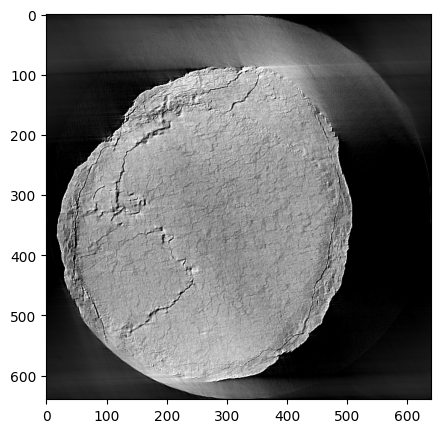

In [18]:
plt.imshow(diffusion_recon[0].cpu().detach(), cmap='gray', vmin=vmin, vmax=vmax)

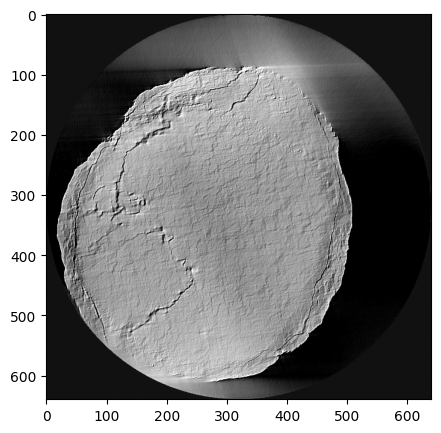

In [19]:
diffusion_recon = diffusion_recon.mean(dim=0).repeat(NUM_SLICES, 1, 1)

diffusion_recon = apply_circle_mask(inpaint_guidance(
    source_volume=gt_fbp.to(device),              # oracle: original full-angle tensor on device
    vol_init=diffusion_recon.to(device),
))

plt.imshow(apply_circle_mask(diffusion_recon[:]).mean(dim=0).cpu().detach(), cmap='gray', vmin=vmin, vmax=vmax)

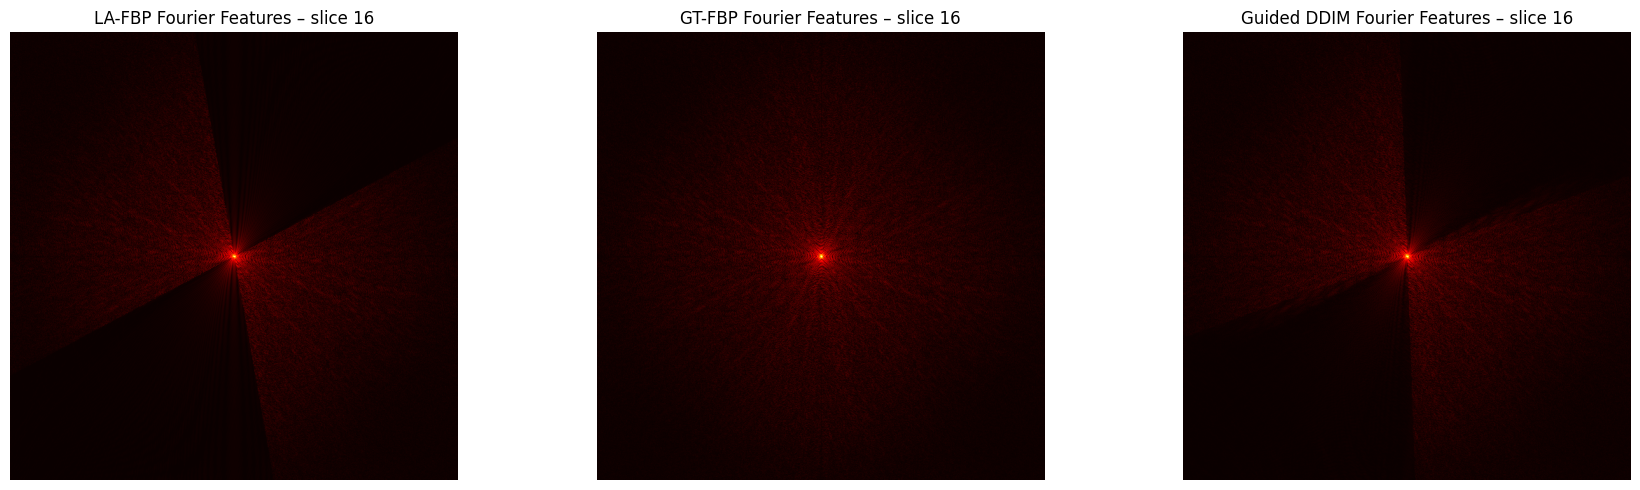

In [20]:
import torch


def fft_2D(x, s=None, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    if ortho:
        fft_image = torch.fft.fftn(x, s=s, norm='ortho', dim=dim)
    else:
        fft_image = torch.fft.fftn(x, s=s, dim=dim)
    return torch.fft.fftshift(fft_image, dim=dim)


def ifft_2D(x, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    f_space = torch.fft.ifftshift(x, dim=dim)
    # Perform inverse 2D Fourier Transform
    if ortho:
        return torch.fft.ifftn(f_space, norm='ortho', dim=dim)
    else:
        return torch.fft.ifftn(f_space, dim=dim)
    


fft_idx = PREVIEW_IDX if 'PREVIEW_IDX' in globals() else 0

fft_inputs = {
    'LA-FBP': la_fbp[fft_idx],
    'GT-FBP': gt_fbp[fft_idx],
    'Guided DDIM': diffusion_recon[fft_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, image) in zip(axes, fft_inputs.items()):
    fft_recon = fft_2D(image)
    magnitude = torch.log1p(torch.abs(fft_recon))
    ax.imshow(magnitude.cpu().detach(), cmap='hot')
    ax.set_title(f'{title} Fourier Features – slice {fft_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Multi-Slice Evaluation

Sweep over selected slices, compute per-slice PSNR / SSIM, and report aggregate statistics.

In [21]:
from tqdm import tqdm
TEST_SLICE_INDICES = None
# Determine which slices to evaluate
if TEST_SLICE_INDICES is not None:
    eval_slices = list(TEST_SLICE_INDICES)
else:
    eval_slices = list(range(0, NUM_SLICES))

print(f"Evaluating {len(eval_slices)} slices: {eval_slices[:5]}{'...' if len(eval_slices) > 5 else ''}")

results = []
for k in tqdm(eval_slices, desc='DDIM inference'):
    ddim_recon = diffusion_recon[k].cpu().numpy()  # (H, W)
    gt_k  = gt_fbp[k].numpy()
    la_k  = la_fbp[k].numpy()
    dr    = gt_k.max() - gt_k.min()

    psnr_d = compute_psnr(gt_k, ddim_recon, data_range=dr)
    ssim_d = compute_ssim(gt_k, ddim_recon, data_range=dr)
    psnr_l = compute_psnr(gt_k, la_k,       data_range=dr)
    ssim_l = compute_ssim(gt_k, la_k,       data_range=dr)

    results.append({
        'slice':     k,
        'psnr_ddim': psnr_d,
        'ssim_ddim': ssim_d,
        'psnr_la':   psnr_l,
        'ssim_la':   ssim_l,
        'ddim_recon': ddim_recon,
        'la_fbp': la_k,
    })
    torch.cuda.empty_cache()

print("\nDone.")


Evaluating 32 slices: [0, 1, 2, 3, 4]...


DDIM inference: 100%|██████████| 32/32 [00:01<00:00, 24.57it/s]


Done.


## 10. Metrics Summary

 Slice   DDIM PSNR  DDIM SSIM   LA-FBP PSNR  LA-FBP SSIM
------------------------------------------------------------
     0       26.05     0.6265         25.29       0.6288
     1       26.05     0.6265         25.29       0.6288
     2       26.05     0.6265         25.29       0.6288
     3       26.05     0.6265         25.29       0.6288
     4       26.05     0.6265         25.29       0.6288
     5       26.05     0.6265         25.29       0.6288
     6       26.05     0.6265         25.29       0.6288
     7       26.05     0.6265         25.29       0.6288
     8       26.05     0.6265         25.29       0.6288
     9       26.05     0.6265         25.29       0.6288
    10       26.05     0.6265         25.29       0.6288
    11       26.05     0.6265         25.29       0.6288
    12       26.05     0.6265         25.29       0.6288
    13       26.05     0.6265         25.29       0.6288
    14       26.05     0.6265         25.29       0.6288
    15       26.05     0.62

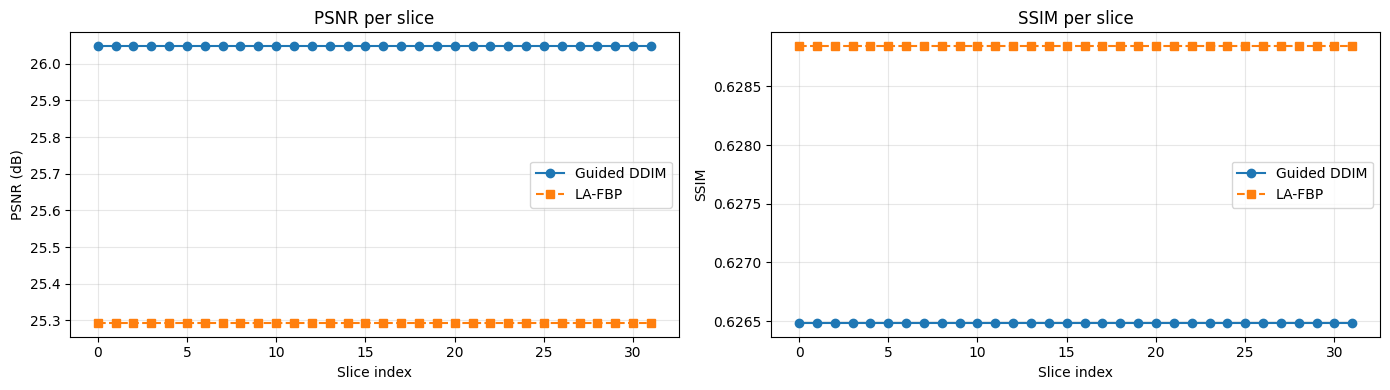

In [22]:
psnr_ddim_all = [r['psnr_ddim'] for r in results]
ssim_ddim_all = [r['ssim_ddim'] for r in results]
psnr_la_all   = [r['psnr_la']   for r in results]
ssim_la_all   = [r['ssim_la']   for r in results]
slices_all    = [r['slice']      for r in results]

# ── Per-slice table ───────────────────────────────────────────────────────
print(f"{'Slice':>6}  {'DDIM PSNR':>10} {'DDIM SSIM':>10}  {'LA-FBP PSNR':>12} {'LA-FBP SSIM':>12}")
print("-" * 60)
for r in results:
    print(f"{r['slice']:>6d}  {r['psnr_ddim']:>10.2f} {r['ssim_ddim']:>10.4f}  "
          f"{r['psnr_la']:>12.2f} {r['ssim_la']:>12.4f}")
print("-" * 60)
print(f"{'Mean':>6}  {np.mean(psnr_ddim_all):>10.2f} {np.mean(ssim_ddim_all):>10.4f}  "
      f"{np.mean(psnr_la_all):>12.2f} {np.mean(ssim_la_all):>12.4f}")
print(f"{'Std':>6}  {np.std(psnr_ddim_all):>10.2f} {np.std(ssim_ddim_all):>10.4f}  "
      f"{np.std(psnr_la_all):>12.2f} {np.std(ssim_la_all):>12.4f}")

# ── PSNR / SSIM over slices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(slices_all, psnr_ddim_all, 'o-', label='Guided DDIM')
axes[0].plot(slices_all, psnr_la_all,   's--', label='LA-FBP')
axes[0].set_xlabel('Slice index')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR per slice')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(slices_all, ssim_ddim_all, 'o-', label='Guided DDIM')
axes[1].plot(slices_all, ssim_la_all,   's--', label='LA-FBP')
axes[1].set_xlabel('Slice index')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM per slice')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Visual Comparison Gallery

In [23]:
# optimizer = torch.optim.AdamW(
#     model.parameters()
# )
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
# }, CHECKPOINT_PATH)

/tmp/ipykernel_1074/1829170448.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err   = gt - ddim
/tmp/ipykernel_1074/1829170448.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err   = gt - la_k


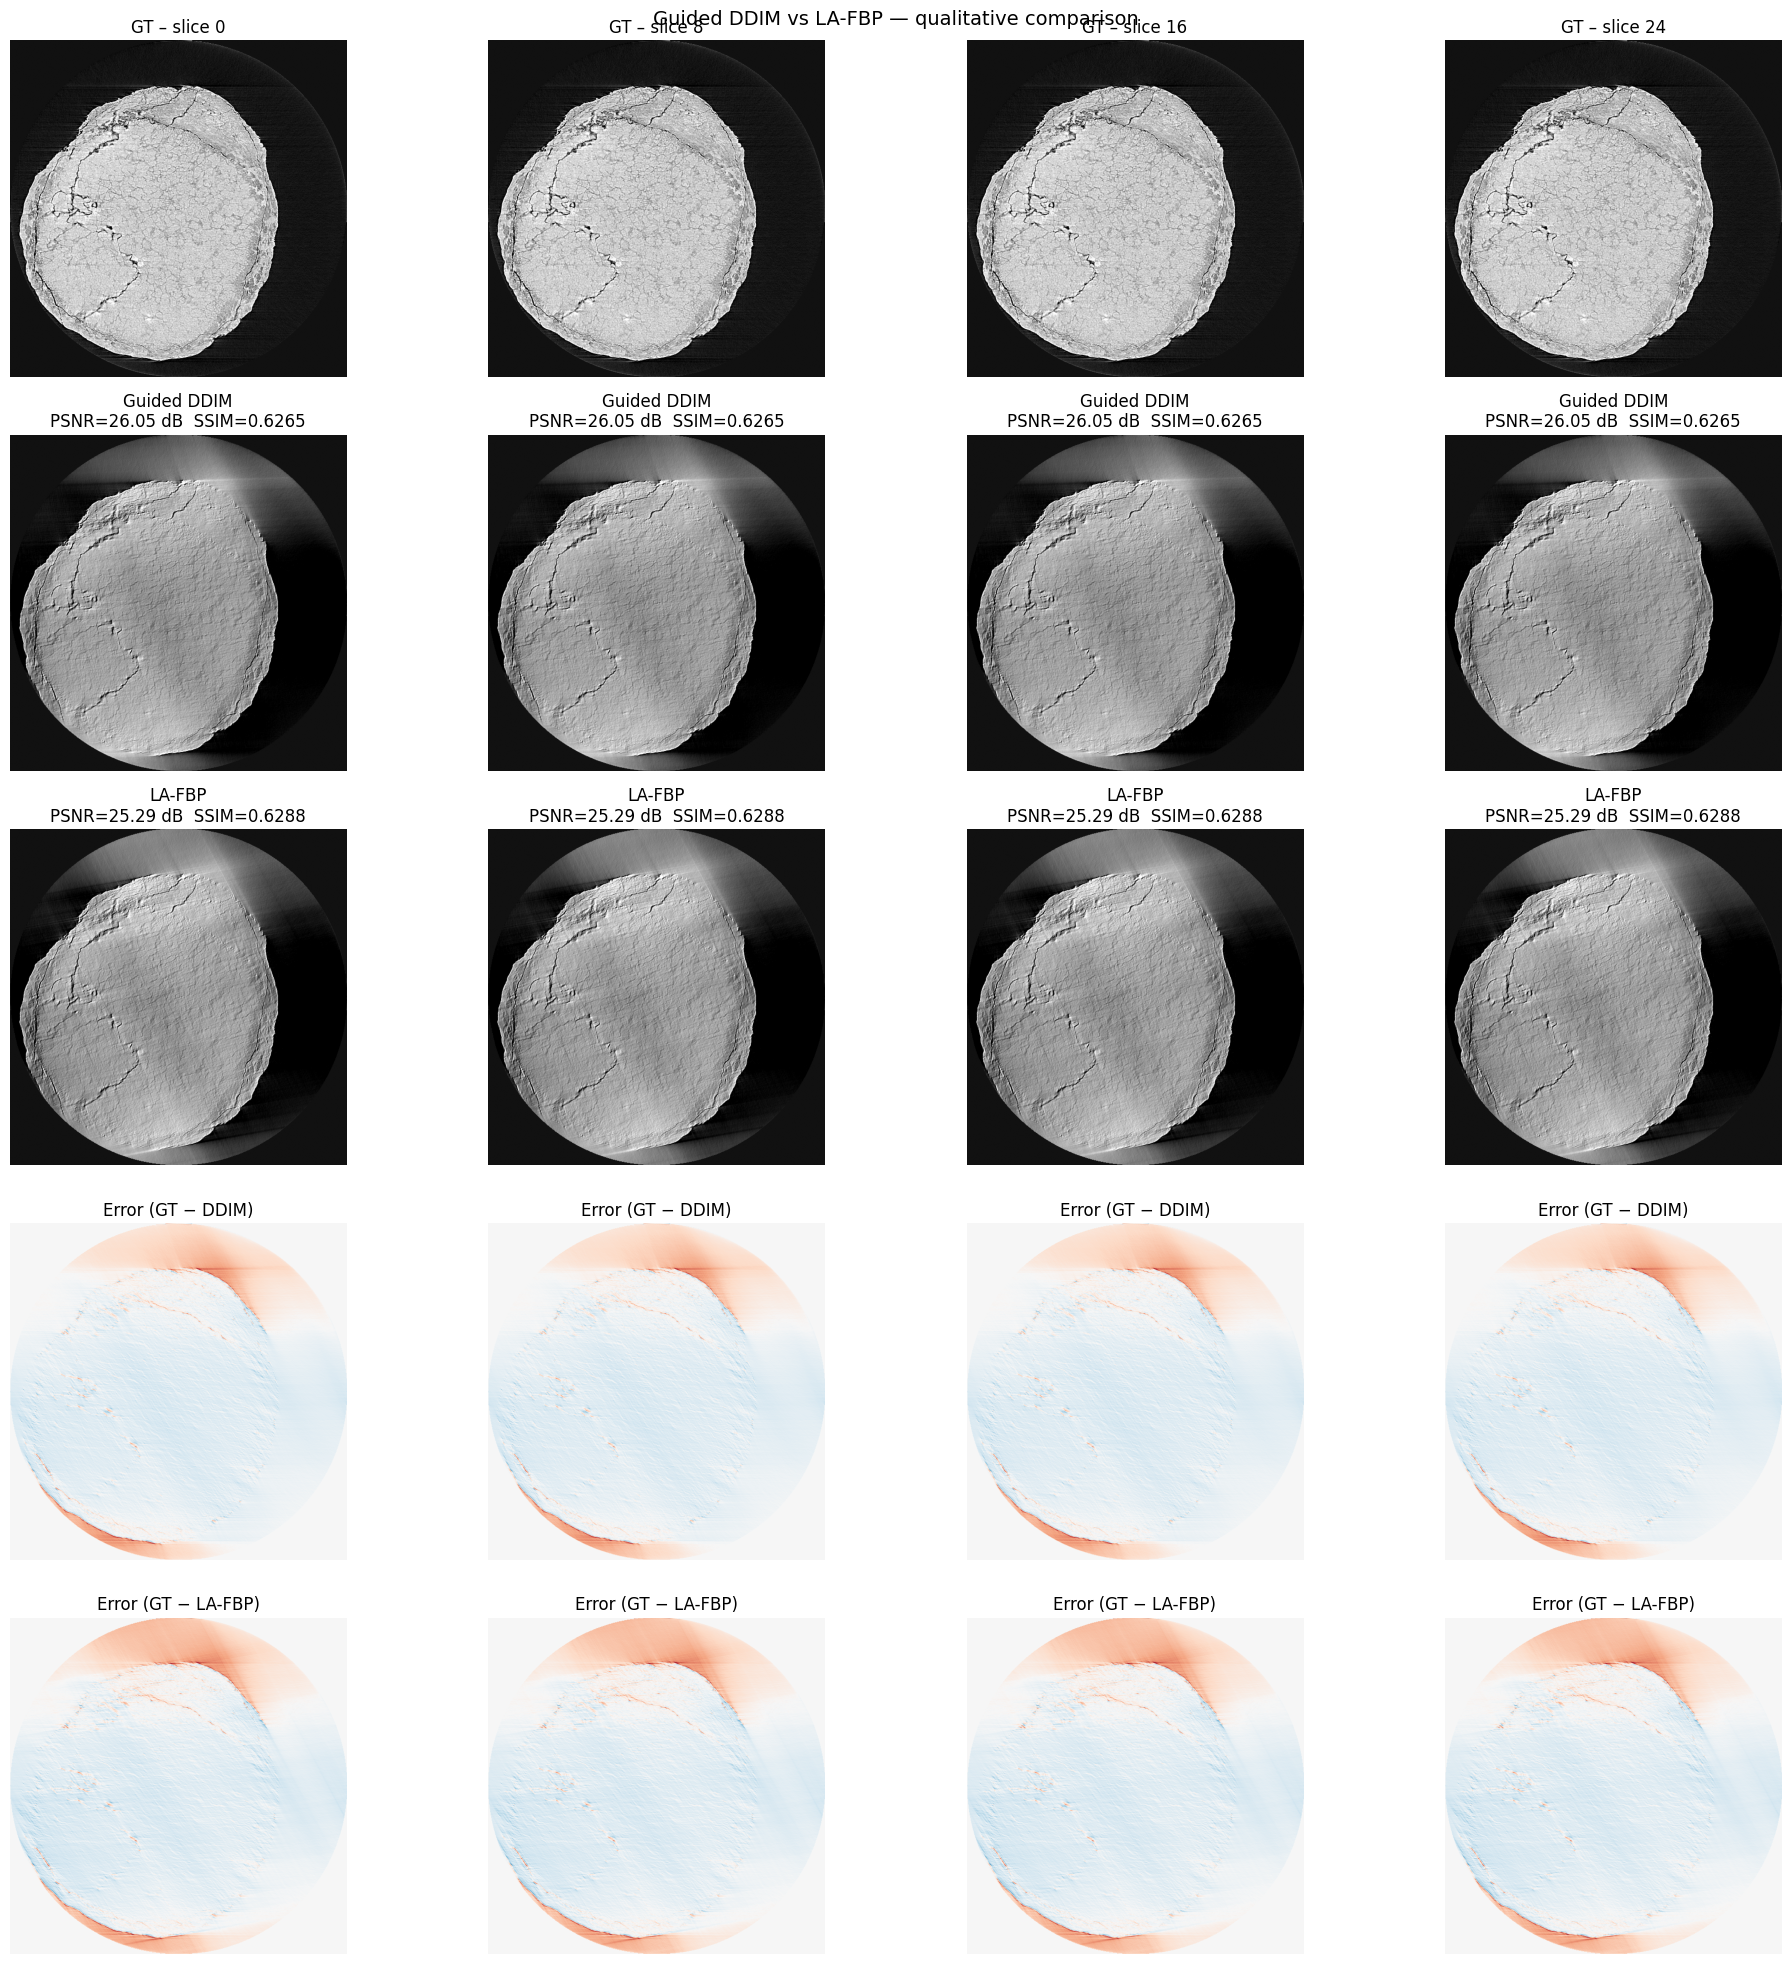

In [24]:
# Show GT | DDIM | LA-FBP | error maps for up to 4 evenly-spaced results
show_results = results[::max(1, len(results) // 4)][:4]
ncols = len(show_results)

fig, axes = plt.subplots(5, ncols, figsize=(5 * ncols, 20))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, r in enumerate(show_results):
    k   = r['slice']
    gt  = gt_fbp[k]
    la  = la_fbp[k]
    ddim = r['ddim_recon']
    la_k = r['la_fbp']
    vmin, vmax = np.percentile(gt, [1, 99])

    axes[0, col].imshow(gt,   cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'GT – slice {k}');    axes[0, col].axis('off')

    axes[1, col].imshow(ddim, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'Guided DDIM\nPSNR={r["psnr_ddim"]:.2f} dB  SSIM={r["ssim_ddim"]:.4f}')
    axes[1, col].axis('off')

    axes[2, col].imshow(la,   cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, col].set_title(f'LA-FBP\nPSNR={r["psnr_la"]:.2f} dB  SSIM={r["ssim_la"]:.4f}')
    axes[2, col].axis('off')

    err   = gt - ddim
    emax  = max(abs(err.min()), abs(err.max()))
    axes[3, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[3, col].set_title(f'Error (GT − DDIM)');  axes[3, col].axis('off')

    err   = gt - la_k
    emax  = max(abs(err.min()), abs(err.max()))
    axes[4, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[4, col].set_title(f'Error (GT − LA-FBP)');  axes[4, col].axis('off')

plt.suptitle('Guided DDIM vs LA-FBP — qualitative comparison', fontsize=14)
plt.tight_layout()
plt.show()


# Saving Results

In [ ]:
import os
import json

PATH = f"/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction"
# make sure the directory exists
os.makedirs(PATH, exist_ok=True)

diffusion_np = diffusion_recon.cpu().numpy()

np.save(PATH + f"/diffusion_{FILE_IDX}_1_round.npy", diffusion_np)

## 12. Iterative Refinement Loop

Re-run the guided DDIM pipeline 5 outer iterations.  
Within each outer iteration we sweep `start_step` from 0.1 → 0.9 (5 values), so each iteration applies progressively coarser denoising passes on top of the current estimate.  
PSNR / SSIM on the middle slice are tracked at every inner step.

In [25]:
from tqdm.auto import tqdm

NUM_INFERENCE_STEPS_ITER = 40
START_STEP_FRACS = [0.85]
NUM_OUTER_ITERS  = 200

# ── Reset reconstruction to LA-FBP baseline ───────────────────────────────
iterative_recon = la_fbp.clone().to(device)

iter_metrics   = []   # {outer_iter, start_step_frac, psnr_full, ssim_full, psnr_mean, ssim_mean}
iter_snapshots = {}   # (outer_iter, start_step_frac) → {'full': np, 'mean': np}

mid       = NUM_SLICES // 2
gt_mid_np = gt_fbp[mid].numpy()
dr_mid    = gt_mid_np.max() - gt_mid_np.min()

for outer_iter in range(NUM_OUTER_ITERS):
    print(f"\n── Outer iteration {outer_iter + 1}/{NUM_OUTER_ITERS} ──────────────────────────")
    for start_step_frac in START_STEP_FRACS:
        torch.cuda.empty_cache()

        # Recreate scheduler so its internal state is clean
        _sched = GuidedDDIMScheduler(
            num_train_timesteps=1000,
            guidance_function=guidance,
        )
        _pipe = DDIMPipeline(
            unet=model.to(device),
            scheduler=_sched,
            fdk_prior=None,
            normalize_fn=normalize_fn,
            denormalize_fn=denormalize_fn,
            slice_batch_size=32,
        )

        result = _pipe.truncated_pipeline(
            initial_guess=iterative_recon.to(device),
            start_step=int(start_step_frac * NUM_INFERENCE_STEPS_ITER),
            num_inference_steps=NUM_INFERENCE_STEPS_ITER,
            use_clipped_model_output=True,
        )
        iterative_recon = result.images.squeeze(0)
    

        # iterative_recon = apply_circle_mask(inpaint_guidance(
        #     source_volume=gt_fbp.to(device),
        #     vol_init=iterative_recon.to(device),
        # ))

        # ── Mean reconstruction: average across the batch of slices ──────
        # (all slices are treated as a batch; the mean collapses noise variance)
        mean_recon = iterative_recon.mean(dim=0).repeat(NUM_SLICES, 1, 1)

        mean_recon = apply_circle_mask(inpaint_guidance(
            source_volume=gt_fbp.to(device),
            vol_init=mean_recon.to(device),
        ))

        # ── Metrics: middle slice, before and after mean ──────────────────
        full_mid_np = iterative_recon[mid].cpu().numpy()
        mean_mid_np = mean_recon[mid].cpu().numpy()

        psnr_full = compute_psnr(gt_mid_np, full_mid_np, data_range=dr_mid)
        ssim_full = compute_ssim(gt_mid_np, full_mid_np, data_range=dr_mid)
        psnr_mean = compute_psnr(gt_mid_np, mean_mid_np, data_range=dr_mid)
        ssim_mean = compute_ssim(gt_mid_np, mean_mid_np, data_range=dr_mid)

        iter_metrics.append({
            'outer_iter':      outer_iter,
            'start_step_frac': start_step_frac,
            'psnr_full':       psnr_full,
            'ssim_full':       ssim_full,
            'psnr_mean':       psnr_mean,
            'ssim_mean':       ssim_mean,
        })
        iter_snapshots[(outer_iter, start_step_frac)] = {
            'full': full_mid_np.copy(),
            'mean': mean_mid_np.copy(),
        }

        print(f"  start_step={start_step_frac:.1f}  "
              f"PSNR full={psnr_full:.2f} dB  SSIM full={ssim_full:.4f}  |  "
              f"PSNR mean={psnr_mean:.2f} dB  SSIM mean={ssim_mean:.4f}")

        # ── Next initial guess is the mean reconstruction ─────────────────
        iterative_recon = mean_recon.to(device)

print("\nIterative refinement done ✓")


── Outer iteration 1/200 ──────────────────────────


100%|██████████| 6/6 [00:06<00:00,  1.05s/it]


  start_step=0.8  PSNR full=25.81 dB  SSIM full=0.4953  |  PSNR mean=26.10 dB  SSIM mean=0.6261

── Outer iteration 2/200 ──────────────────────────


100%|██████████| 6/6 [00:07<00:00,  1.23s/it]


  start_step=0.8  PSNR full=26.21 dB  SSIM full=0.5176  |  PSNR mean=26.40 dB  SSIM mean=0.6252

── Outer iteration 3/200 ──────────────────────────


...

  start_step=0.8  PSNR full=31.71 dB  SSIM full=0.7685  |  PSNR mean=32.13 dB  SSIM mean=0.7951

── Outer iteration 199/200 ──────────────────────────


100%|██████████| 6/6 [00:07<00:00,  1.24s/it]


  start_step=0.8  PSNR full=31.68 dB  SSIM full=0.7624  |  PSNR mean=32.12 dB  SSIM mean=0.7945

── Outer iteration 200/200 ──────────────────────────


100%|██████████| 6/6 [00:07<00:00,  1.24s/it]

  start_step=0.8  PSNR full=31.72 dB  SSIM full=0.7710  |  PSNR mean=32.13 dB  SSIM mean=0.7952

Iterative refinement done ✓


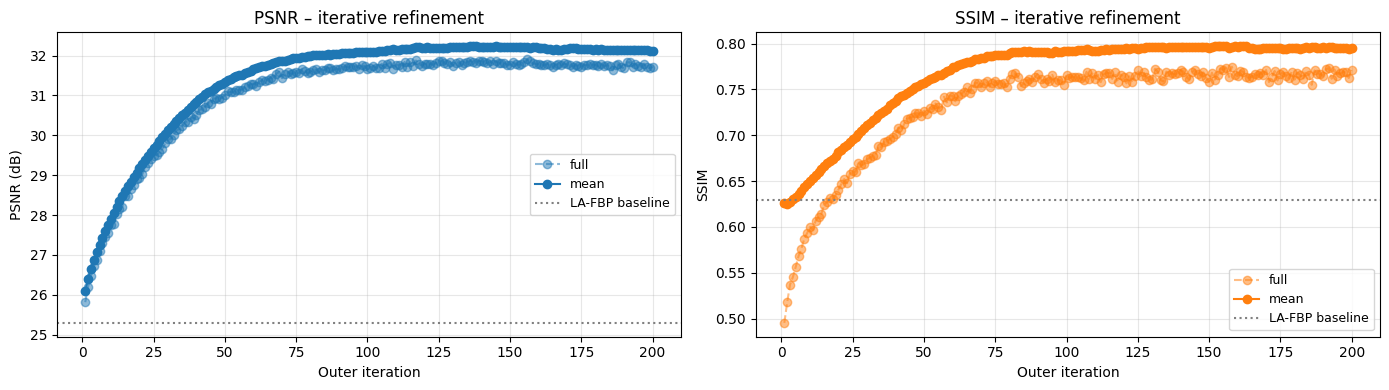

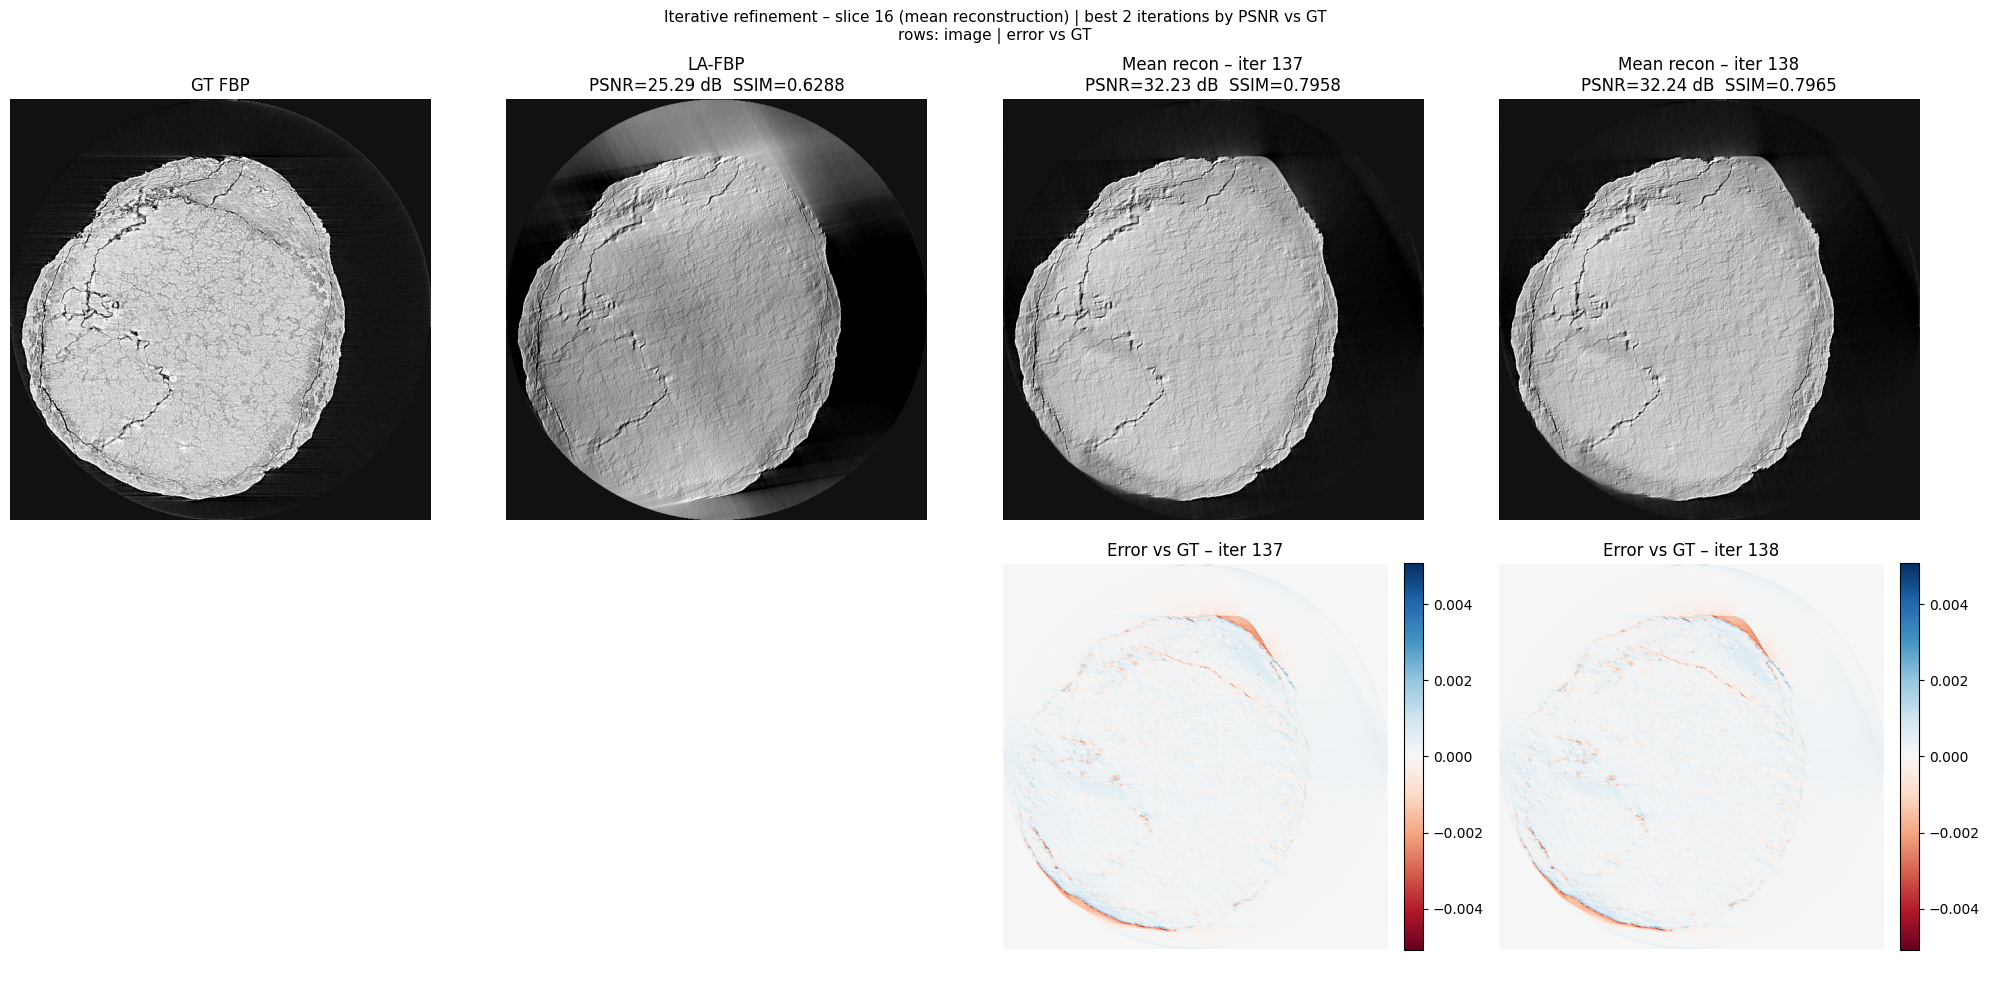

In [27]:
psnr_la_base = compute_psnr(gt_mid_np, la_fbp[mid].numpy(), data_range=dr_mid)
ssim_la_base = compute_ssim(gt_mid_np, la_fbp[mid].numpy(), data_range=dr_mid)

# ── Metric curves: full-slice and mean vs outer iteration ─────────────────
iters_x   = [x['outer_iter'] + 1 for x in iter_metrics]
psnr_full = [x['psnr_full']      for x in iter_metrics]
psnr_mean = [x['psnr_mean']      for x in iter_metrics]
ssim_full = [x['ssim_full']      for x in iter_metrics]
ssim_mean = [x['ssim_mean']      for x in iter_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(iters_x, psnr_full, 'o--', color='C0', alpha=0.5, label='full')
axes[0].plot(iters_x, psnr_mean, 'o-',  color='C0',             label='mean')
axes[0].axhline(psnr_la_base, color='gray', ls=':', lw=1.5, label='LA-FBP baseline')
axes[0].set_xlabel('Outer iteration')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR – iterative refinement')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters_x, ssim_full, 'o--', color='C1', alpha=0.5, label='full')
axes[1].plot(iters_x, ssim_mean, 'o-',  color='C1',             label='mean')
axes[1].axhline(ssim_la_base, color='gray', ls=':', lw=1.5, label='LA-FBP baseline')
axes[1].set_xlabel('Outer iteration')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM – iterative refinement')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Qualitative gallery – best 2 iterations vs GT ─────────────────────────
# Pick the two outer iterations with highest mean-recon PSNR vs GT
sorted_by_psnr = sorted(iter_metrics, key=lambda x: x['psnr_mean'], reverse=True)
best_iters = [sorted_by_psnr[0]['outer_iter'], sorted_by_psnr[1]['outer_iter']]
best_iters_sorted = sorted(best_iters)  # display in chronological order

vmin_i, vmax_i = np.percentile(gt_mid_np, [1, 99])

# Columns: GT | LA-FBP | best_iter_1 | best_iter_2
ncols = 4
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 10))

# Row 0 – images
axes[0, 0].imshow(gt_mid_np,           cmap='gray', vmin=vmin_i, vmax=vmax_i)
axes[0, 0].set_title('GT FBP');        axes[0, 0].axis('off')
axes[0, 1].imshow(la_fbp[mid].numpy(), cmap='gray', vmin=vmin_i, vmax=vmax_i)
axes[0, 1].set_title(f'LA-FBP\nPSNR={psnr_la_base:.2f} dB  SSIM={ssim_la_base:.4f}')
axes[0, 1].axis('off')

# Row 1 – errors vs GT (only for recon columns; blank for GT and LA-FBP)
axes[1, 0].axis('off')
axes[1, 1].axis('off')

for col, oi in enumerate(best_iters_sorted, start=2):
    snap       = iter_snapshots[(oi, START_STEP_FRACS[-1])]
    mean_recon = snap['mean']
    psnr_m = compute_psnr(gt_mid_np, mean_recon, data_range=dr_mid)
    ssim_m = compute_ssim(gt_mid_np, mean_recon, data_range=dr_mid)

    axes[0, col].imshow(mean_recon, cmap='gray', vmin=vmin_i, vmax=vmax_i)
    axes[0, col].set_title(f'Mean recon – iter {oi+1}\nPSNR={psnr_m:.2f} dB  SSIM={ssim_m:.4f}')
    axes[0, col].axis('off')

    err  = gt_mid_np - mean_recon
    emax = max(abs(err.min()), abs(err.max()))
    im = axes[1, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[1, col].set_title(f'Error vs GT – iter {oi+1}')
    axes[1, col].axis('off')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)

plt.suptitle(
    f'Iterative refinement – slice {mid} (mean reconstruction) | best 2 iterations by PSNR vs GT\n'
    f'rows: image | error vs GT',
    fontsize=11,
)
plt.tight_layout()
plt.show()